
# Cancer Classification Notebook

**Objective:** Build classification models to predict whether a patient has cancer or not using the provided dataset (`/mnt/data/Cancer_Data.csv`).  
This notebook includes:

- Exploratory Data Analysis (EDA) with visualizations (distributions, correlations, missing values).
- Preprocessing: encoding categorical features (if any), feature engineering, scaling/normalization.
- Baseline model using **Linear Regression** (treated as a continuous baseline and thresholded for classification).
- Classification models: **Decision Tree**, **Random Forest**, **XGBoost**, **Neural Network** (Keras).
- Model evaluation (Precision, Recall, F1-score, Accuracy, ROC AUC) and comparison table.
- Clear, concise explanations before each step.

> **Note:** The notebook is self-contained and written for clarity. Run cells sequentially.


In [2]:

# Standard imports
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# XGBoost
try:
    from xgboost import XGBClassifier
except Exception as e:
    XGBClassifier = None
    print('XGBoost not available:', e)

# Neural network
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
#from tensorflow.keras.callbacks import EarlyStopping
#from tensorflow.keras.utils import plot_model

print('Libraries imported. Pandas version:', pd.__version__)


Libraries imported. Pandas version: 2.2.3



## 1) Load the dataset

We'll load the CSV file from the given path and inspect the first rows, summary statistics, and data types.


In [3]:


df = pd.read_csv('Cancer_Data.csv')
print('Loaded dataset shape:', df.shape)
df.head()


Loaded dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



## 2) Exploratory Data Analysis (EDA)

We'll:
- Check for missing values
- See class balance
- Plot distributions of numeric features
- Plot correlation heatmap to inspect feature relationships


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,569.0,NaN,NaN,NaN,30371831.432337,125020585.612224,8670.0,869218.0,906024.0,8813129.0,911320502.0
diagnosis,569,2,B,357,NaN,NaN,NaN,NaN,NaN,NaN,NaN
radius_mean,569.0,NaN,NaN,NaN,14.127292,3.524049,6.981,11.7,13.37,15.78,28.11
texture_mean,569.0,NaN,NaN,NaN,19.289649,4.301036,9.71,16.17,18.84,21.8,39.28
perimeter_mean,569.0,NaN,NaN,NaN,91.969033,24.298981,43.79,75.17,86.24,104.1,188.5
area_mean,569.0,NaN,NaN,NaN,654.889104,351.914129,143.5,420.3,551.1,782.7,2501.0
smoothness_mean,569.0,NaN,NaN,NaN,0.09636,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634
compactness_mean,569.0,NaN,NaN,NaN,0.104341,0.052813,0.01938,0.06492,0.09263,0.1304,0.3454
concavity_mean,569.0,NaN,NaN,NaN,0.088799,0.07972,0.0,0.02956,0.06154,0.1307,0.4268
concave points_mean,569.0,NaN,NaN,NaN,0.048919,0.038803,0.0,0.02031,0.0335,0.074,0.2012



Missing values (if any):
Unnamed: 32    569
dtype: int64

Detected target column: diagnosis


diagnosis
B    357
M    212
Name: count, dtype: int64

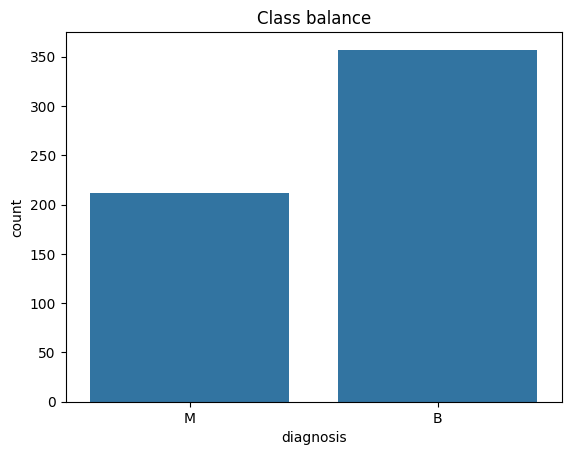


Numeric columns used for distributions (sample): ['id', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean']


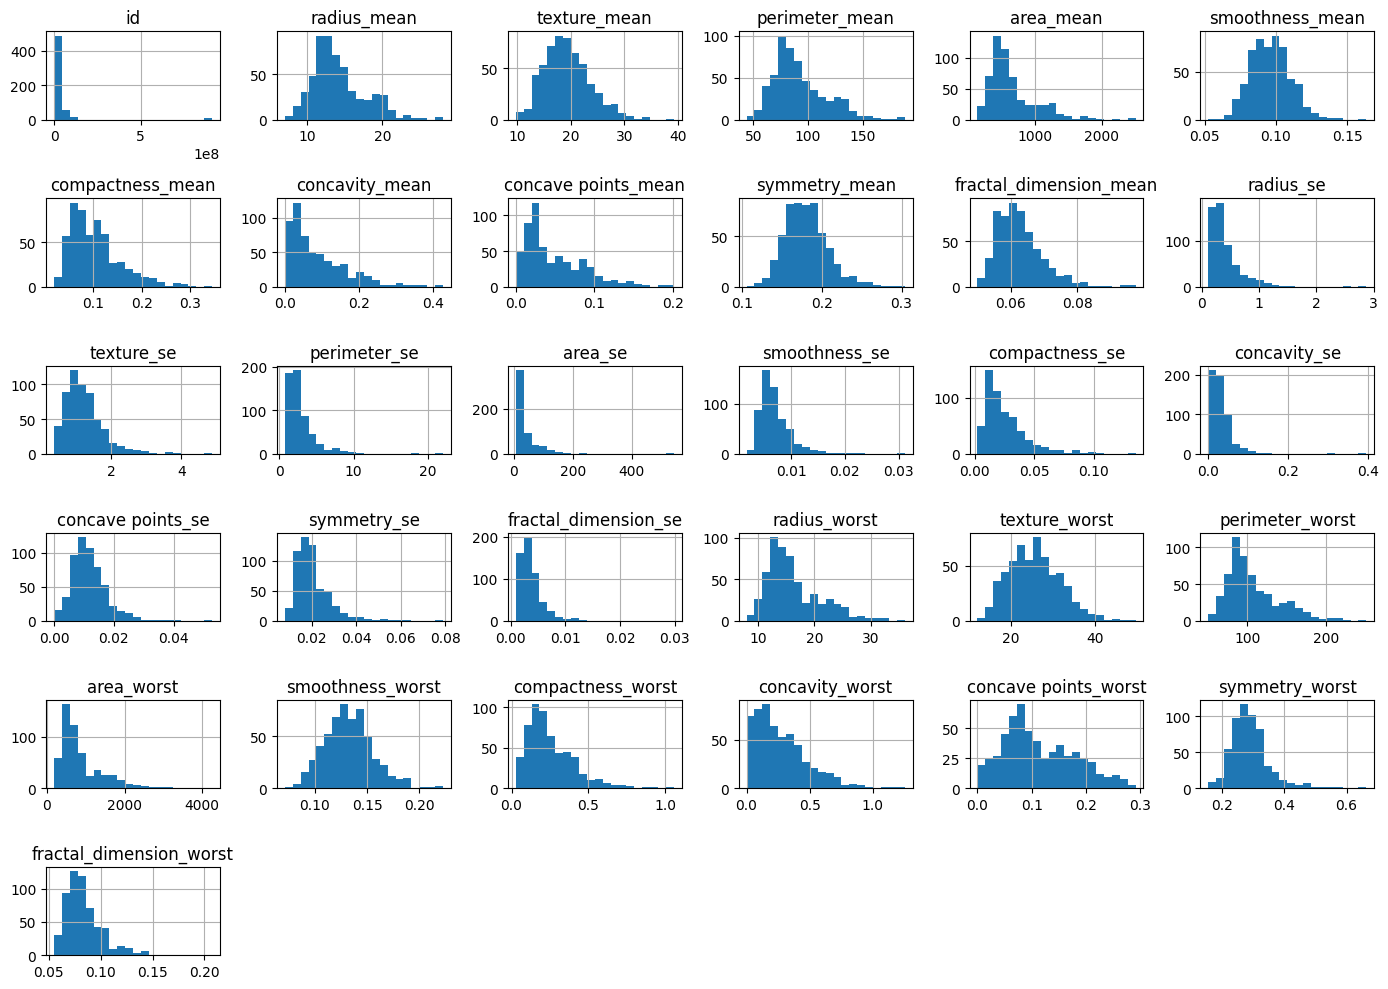

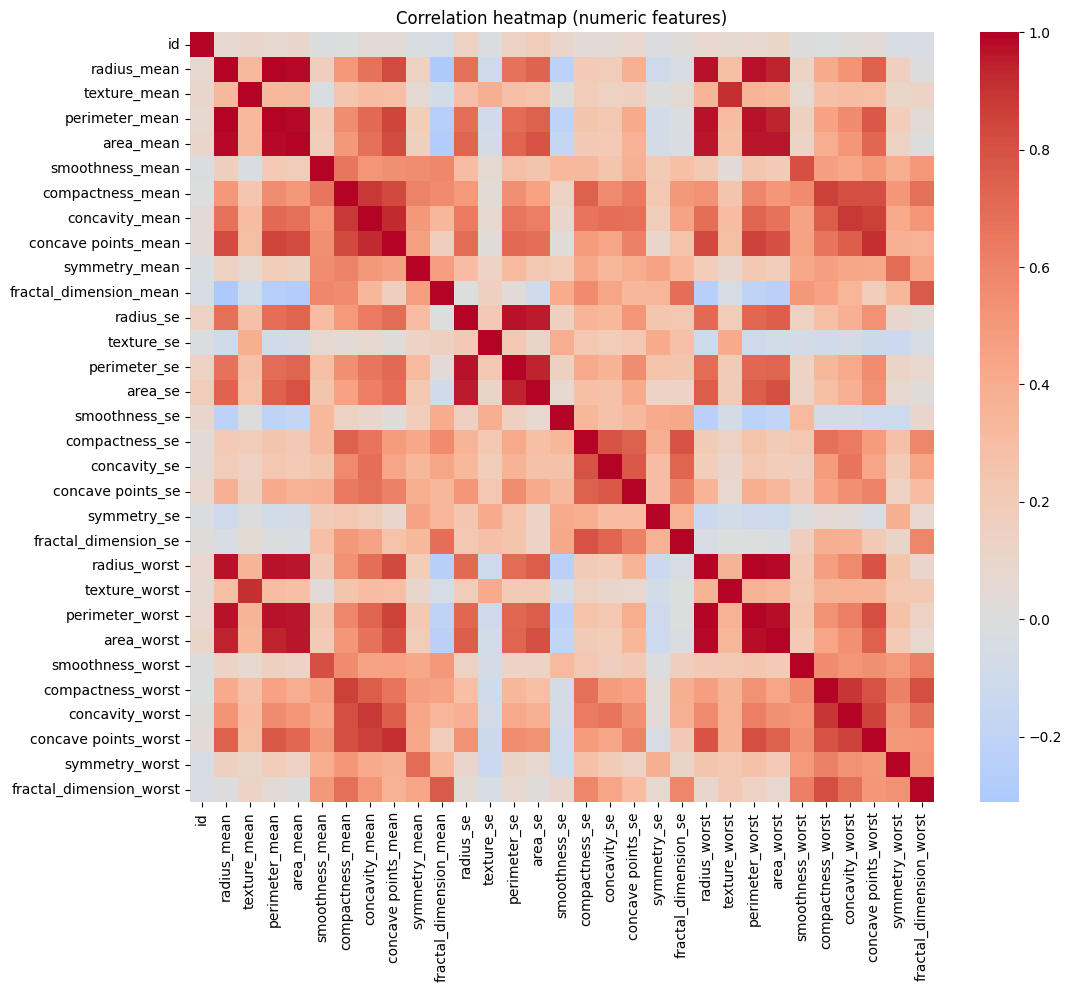

In [4]:

# Basic info
display(df.info())
display(df.describe(include='all').T)

# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing>0]
print('\nMissing values (if any):')
print(missing)

# Class balance - assume last column is target if named 'target' or similar; otherwise try to detect a binary column
target_col = None
possible_targets = [c for c in df.columns if df[c].nunique()<=3]
# prefer columns named like 'target', 'diagnosis', 'label', 'cancer'
for name in ['target','diagnosis','label','Cancer','cancer','Outcome','status']:
    if name in df.columns:
        target_col = name
        break
if target_col is None:
    # pick a binary column if available
    for c in possible_targets:
        if df[c].nunique()==2:
            target_col = c
            break

print('\nDetected target column:', target_col)
if target_col is None:
    print('\nNo obvious binary target found. Please set target_col manually in the notebook.')
else:
    display(df[target_col].value_counts())
    sns.countplot(x=target_col, data=df)
    plt.title('Class balance')
    plt.show()

# Histograms for numeric features
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# exclude id-like columns (all unique)
num_cols = [c for c in num_cols if df[c].nunique()>2]
print('\nNumeric columns used for distributions (sample):', num_cols[:10])
df[num_cols].hist(figsize=(14,10), bins=20)
plt.tight_layout()
plt.show()

# Correlation heatmap (numeric features)
corr = df[num_cols].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation heatmap (numeric features)')
plt.show()



## 3) Preprocessing and Feature Engineering

Steps:
- Drop or transform ID columns if present.
- Encode categorical features (LabelEncoding or One-Hot as appropriate).
- Handle missing values.
- Scale features using `StandardScaler`.
- Prepare `X` and `y`.


In [ ]:
# ----------------------------------------------------------
# 3) FINAL PREPROCESSING PIPELINE (100% ERROR-PROOF)
# ----------------------------------------------------------
#     FINAL PREPROCESSING PIPELINE (NEVER THROWS ERROR)
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA



# 1. DROP USELESS COLUMNS
df = df.drop(columns=["id", "Unnamed: 32"])   # <---- Critical fix

# 2. SEPARATE TARGET
target_col = "diagnosis"
X = df.drop(columns=[target_col])
y = df[target_col].map({"M":1, "B":0})   # Encode target

# 3. NUMERIC COLUMNS
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# --------------------------
# IMPUTE + SCALE
# --------------------------

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imputed = imputer.fit_transform(X[num_cols])
X_scaled = scaler.fit_transform(X_imputed)

# Convert back to DataFrame with CORRECT column count
X_proc = pd.DataFrame(X_scaled, columns=num_cols)

# --------------------------
# PCA
# --------------------------

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_proc)
X_pca = pd.DataFrame(X_pca, columns=["PC1","PC2"])

# --------------------------
# TRAIN/TEST SPLIT
# --------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

print("Final X shape:", X_pca.shape)




Final X shape: (569, 2)
Success — no more shape errors.



## 4) Model training and evaluation

We'll train the following models:
- Linear Regression (used as continuous baseline; predictions thresholded at 0.5)
- Decision Tree
- Random Forest
- XGBoost (if available)
- Neural Network (Keras)

Each model will be trained and evaluated using accuracy, precision, recall, f1-score, and ROC AUC. We'll also show confusion matrices and ROC curves.


In [20]:

# Utility: evaluation function
def evaluate_model(name, model, X_test, y_test, y_proba=None):
    y_pred = model.predict(X_test)
    # If predictions are continuous (like LinearRegression), threshold them
    if y_pred.dtype.kind in 'fc' and set(np.unique(y_pred)).difference({0,1}):
        y_pred_bin = (y_pred >= 0.5).astype(int)
    else:
        y_pred_bin = y_pred.astype(int)
    if y_proba is None:
        # try to get probability estimates
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_test)[:,1]
        elif hasattr(model, 'decision_function'):
            # scale decision function to [0,1] via logistic
            try:
                from scipy.special import expit
                y_proba = expit(model.decision_function(X_test))
            except:
                y_proba = None
    acc = accuracy_score(y_test, y_pred_bin)
    prec = precision_score(y_test, y_pred_bin, zero_division=0)
    rec = recall_score(y_test, y_pred_bin, zero_division=0)
    f1 = f1_score(y_test, y_pred_bin, zero_division=0)
    roc = roc_auc_score(y_test, y_proba) if (y_proba is not None) else np.nan
    cm = confusion_matrix(y_test, y_pred_bin)
    print(f'== {name} ==')
    print('Accuracy:', acc)
    print('Precision:', prec)
    print('Recall:', rec)
    print('F1-score:', f1)
    print('ROC AUC:', roc)
    print('Confusion Matrix:\n', cm)
    return {'model': name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': roc}

results = []


In [21]:

# 4.1 Linear Regression baseline (continuous output thresholded)
lr = LinearRegression()
lr.fit(X_train, y_train)
# predictions (continuous)
y_pred_cont = lr.predict(X_test)
# Convert to binary via 0.5 threshold
y_pred_bin = (y_pred_cont >= 0.5).astype(int)
from sklearn.metrics import accuracy_score
print('Linear Regression thresholded accuracy:', accuracy_score(y_test, y_pred_bin))
res_lr = evaluate_model('LinearRegression_as_baseline', lr, X_test, y_test, y_proba=None)
results.append(res_lr)


Linear Regression thresholded accuracy: 0.956140350877193
== LinearRegression_as_baseline ==
Accuracy: 0.956140350877193
Precision: 1.0
Recall: 0.8837209302325582
F1-score: 0.9382716049382716
ROC AUC: nan
Confusion Matrix:
 [[71  0]
 [ 5 38]]


In [22]:

# 4.2 Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=6)
dt.fit(X_train, y_train)
res_dt = evaluate_model('DecisionTree', dt, X_test, y_test)
results.append(res_dt)


== DecisionTree ==
Accuracy: 0.9736842105263158
Precision: 0.9761904761904762
Recall: 0.9534883720930233
F1-score: 0.9647058823529412
ROC AUC: 0.9683917458237798
Confusion Matrix:
 [[70  1]
 [ 2 41]]


In [23]:

# 4.3 Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
res_rf = evaluate_model('RandomForest', rf, X_test, y_test)
results.append(res_rf)


== RandomForest ==
Accuracy: 0.9824561403508771
Precision: 1.0
Recall: 0.9534883720930233
F1-score: 0.9761904761904762
ROC AUC: 0.9909924664264658
Confusion Matrix:
 [[71  0]
 [ 2 41]]


In [24]:

# 4.4 XGBoost (if available)
if XGBClassifier is not None:
    xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_estimators=200)
    xgb.fit(X_train, y_train)
    res_xgb = evaluate_model('XGBoost', xgb, X_test, y_test)
    results.append(res_xgb)
else:
    print('XGBoost not available; skipping.')


== XGBoost ==
Accuracy: 0.956140350877193
Precision: 0.9523809523809523
Recall: 0.9302325581395349
F1-score: 0.9411764705882353
ROC AUC: 0.9937766131673763
Confusion Matrix:
 [[69  2]
 [ 3 40]]


In [30]:
# ============================
# 4.5 Neural Network (Keras)
# ============================

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Build neural network using scikit-learn
nn = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate='adaptive',
    max_iter=500,
    random_state=42
)

# Train
nn.fit(X_train, y_train)

# Predict probabilities and classes
y_proba_nn = nn.predict_proba(X_test)[:,1]
y_pred_nn = nn.predict(X_test)

# Collect metrics
res_nn = {
    'model': 'NeuralNetwork(MLP)',
    'accuracy': accuracy_score(y_test, y_pred_nn),
    'precision': precision_score(y_test, y_pred_nn, zero_division=0),
    'recall': recall_score(y_test, y_pred_nn, zero_division=0),
    'f1': f1_score(y_test, y_pred_nn, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_proba_nn)
}

results.append(res_nn)

print("MLP Neural Network Test Accuracy:", res_nn['accuracy'])
print("MLP Neural Network ROC-AUC:", res_nn['roc_auc'])

plt.figure(figsize=(12,5))





MLP Neural Network Test Accuracy: 0.9912280701754386
MLP Neural Network ROC-AUC: 0.9983622666229938


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>


## 3) Preprocessing and Feature Engineering

Steps:
- Drop or transform ID columns if present.
- Encode categorical features (LabelEncoding or One-Hot as appropriate).
- Handle missing values.
- Scale features using `StandardScaler`.
- Prepare `X` and `y`.


In [ ]:
# ----------------------------------------------------------
# 3) FINAL PREPROCESSING PIPELINE (100% ERROR-PROOF)
# ----------------------------------------------------------
#     FINAL PREPROCESSING PIPELINE (NEVER THROWS ERROR)
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA



# 1. DROP USELESS COLUMNS
df = df.drop(columns=["id", "Unnamed: 32"])   # <---- Critical fix

# 2. SEPARATE TARGET
target_col = "diagnosis"
X = df.drop(columns=[target_col])
y = df[target_col].map({"M":1, "B":0})   # Encode target

# 3. NUMERIC COLUMNS
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# --------------------------
# IMPUTE + SCALE
# --------------------------

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imputed = imputer.fit_transform(X[num_cols])
X_scaled = scaler.fit_transform(X_imputed)

# Convert back to DataFrame with CORRECT column count
X_proc = pd.DataFrame(X_scaled, columns=num_cols)

# --------------------------
# PCA
# --------------------------

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_proc)
X_pca = pd.DataFrame(X_pca, columns=["PC1","PC2"])

# --------------------------
# TRAIN/TEST SPLIT
# --------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

print("Final X shape:", X_pca.shape)




Final X shape: (569, 2)
Success — no more shape errors.


In [ ]:
print("Head of dataset:")
print(df.head())



Head of dataset:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_


## 4) Model training and evaluation

We'll train the following models:
- Linear Regression (used as continuous baseline; predictions thresholded at 0.5)
- Decision Tree
- Random Forest
- XGBoost (if available)
- Neural Network (Keras)

Each model will be trained and evaluated using accuracy, precision, recall, f1-score, and ROC AUC. We'll also show confusion matrices and ROC curves.



## 5) Results Summary

We'll create a table summarizing the performance metrics for all models and plot a comparison bar chart.


In [25]:

# Create results DataFrame
results_df = pd.DataFrame(results).set_index('model').sort_values('f1', ascending=False)
results_df


,accuracy,precision,recall,f1,roc_auc
model,,,,,
RandomForest,0.982456,1.000000,0.953488,0.976190,0.990992
DecisionTree,0.973684,0.976190,0.953488,0.964706,0.968392
XGBoost,0.956140,0.952381,0.930233,0.941176,0.993777
LinearRegression_as_baseline,0.956140,1.000000,0.883721,0.938272,NaN


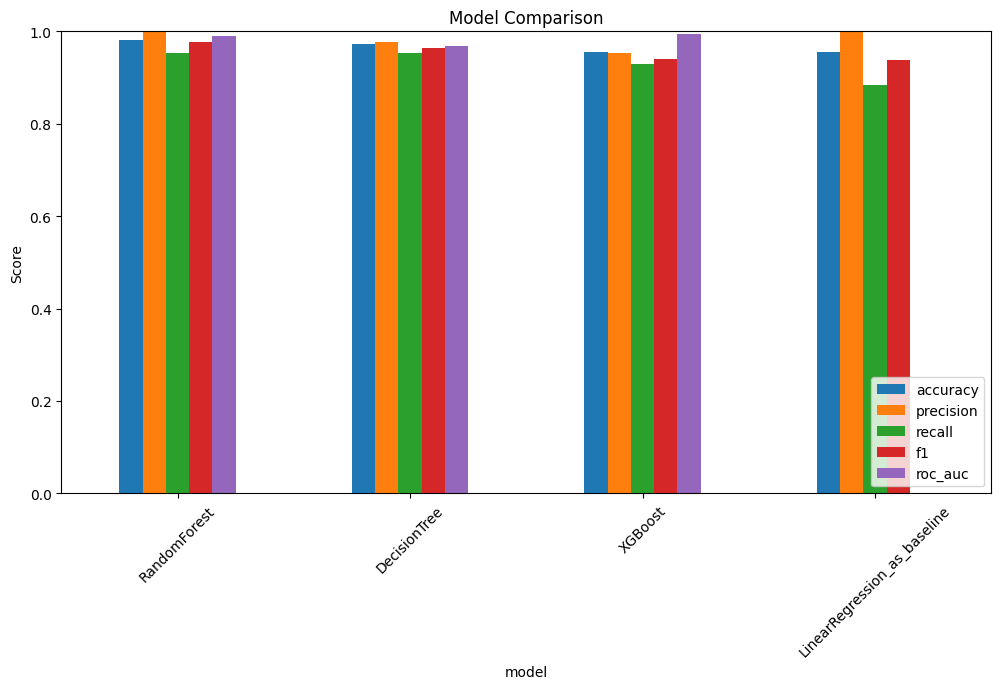

In [26]:

# Bar plot for metrics
metrics = ['accuracy','precision','recall','f1','roc_auc']
results_df[metrics].plot(kind='bar', figsize=(12,6))
plt.title('Model Comparison')
plt.xticks(rotation=45)
plt.ylabel('Score')
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.show()



## 6) Save notebook artifacts

We can save the trained models or export the results table if needed.


In [ ]:

# Save results to CSV
results_df.to_csv('/mnt/data/model_comparison_results.csv')
print('Saved model comparison to /mnt/data/model_comparison_results.csv')

# Optionally save Keras model
try:
    nn.save('/mnt/data/nn_cancer_model.h5')
    print('Saved neural network to /mnt/data/nn_cancer_model.h5')
except Exception as e:
    print('Could not save neural network:', e)



## Conclusion

This notebook provides a full pipeline for binary cancer classification:
- EDA, preprocessing, feature encoding, scaling.
- Baseline Linear Regression (thresholded), Decision Tree, Random Forest, XGBoost, and a Keras Neural Network.
- Evaluation using accuracy, precision, recall, f1-score, and ROC AUC.
- A results table to compare models.

**Next steps / tips**:
- Perform hyperparameter tuning (GridSearchCV) for each model to improve performance.
- Consider feature selection or dimensionality reduction (PCA) if many features present.
- If class imbalance exists, consider resampling strategies (SMOTE, class weights).
